In [9]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt 
from ultralytics import YOLO


feature_maps = {}
gradients = {}

def save_feature_maps(module, input, output):
    """Capture les activations (A) lors du passage avant."""
    feature_maps["A"] = output.detach() 

def save_gradients(module, grad_input, grad_output):
    """Capture les gradients lors du passage arrière."""
    gradients["grads"] = grad_output[0].detach() 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

Appareil utilisé : cuda


In [10]:
def grad_cam_pp_yolo(model, yolo_results, target_layer, input_tensor):
    """
    Calcule la heatmap Grad-CAM++ adaptée à la structure de sortie YOLOv8.
    """
    # Enregistrement des hooks
    forward_handle = target_layer.register_forward_hook(save_feature_maps)
    backward_handle = target_layer.register_full_backward_hook(save_gradients)

    # Passage avant
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad_(True) 
    output = model(input_tensor)

    # Vérification des détections
    if len(yolo_results[0].boxes) == 0:
        forward_handle.remove()
        backward_handle.remove()
        return np.zeros((input_tensor.shape[2], input_tensor.shape[3]))
    
 
    target_class_index = int(yolo_results[0].boxes[0].cls.item())
    
    # YOLOv8 output: [Batch, 4 + nb_classes, 8400]
    class_scores = output[0][0, 4 + target_class_index, :]
    target_score_tensor = torch.max(class_scores)

    # Passage arrière
    model.zero_grad()
    target_score_tensor.backward(retain_graph=True) 

    # Récupération des données capturées
    A = feature_maps["A"].squeeze(0)
    grads = gradients["grads"].squeeze(0)

    # Nettoyage des hooks
    forward_handle.remove()
    backward_handle.remove()
    
    # CALCUL GRAD-CAM++ 
    grads_2 = grads.pow(2)
    grads_3 = grads.pow(3)
    sum_A = A.sum(dim=(1, 2), keepdim=True)

    eps = 1e-8 
    alpha_num = grads_2
    alpha_denom = 2 * grads_2 + sum_A * grads_3 + eps
    alphas = alpha_num / alpha_denom

    weights = (alphas * torch.relu(grads)).sum(dim=(1, 2), keepdim=True) 

    cam = (weights * A).sum(dim=0) 
    cam = torch.relu(cam).detach().cpu().numpy()
    
    if cam.max() > 0:
        cam = cam / cam.max()
        
    heatmap = cv2.resize(cam, (input_tensor.shape[3], input_tensor.shape[2]))

    return heatmap

In [11]:

yolo_model = YOLO("yolov8n.pt") 
model = yolo_model.model.to(device).eval() 


target_layer = model.model[9] 


img_path = "2008_000152.jpg"
img_pil = Image.open(img_path).convert("RGB")
# IMG_SIZE = 640 

# preprocess = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
# ])
# input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
w_orig, h_orig = img_pil.size
target_size = 640
r = target_size / max(h_orig, w_orig)
new_w, new_h = int(w_orig * r), int(h_orig * r)

# Forcer des dimensions multiples de 32 pour YOLO
new_w = (new_w // 32) * 32
new_h = (new_h // 32) * 32
img_final = img_pil.resize((new_w, new_h))

# Conversion en tenseur (Prêt pour le modèle)
input_tensor = transforms.ToTensor()(img_final).unsqueeze(0).to(device)

results = yolo_model.predict(img_path, imgsz=target_size, verbose=False)
heatmap_pp = grad_cam_pp_yolo(model, results, target_layer, input_tensor)

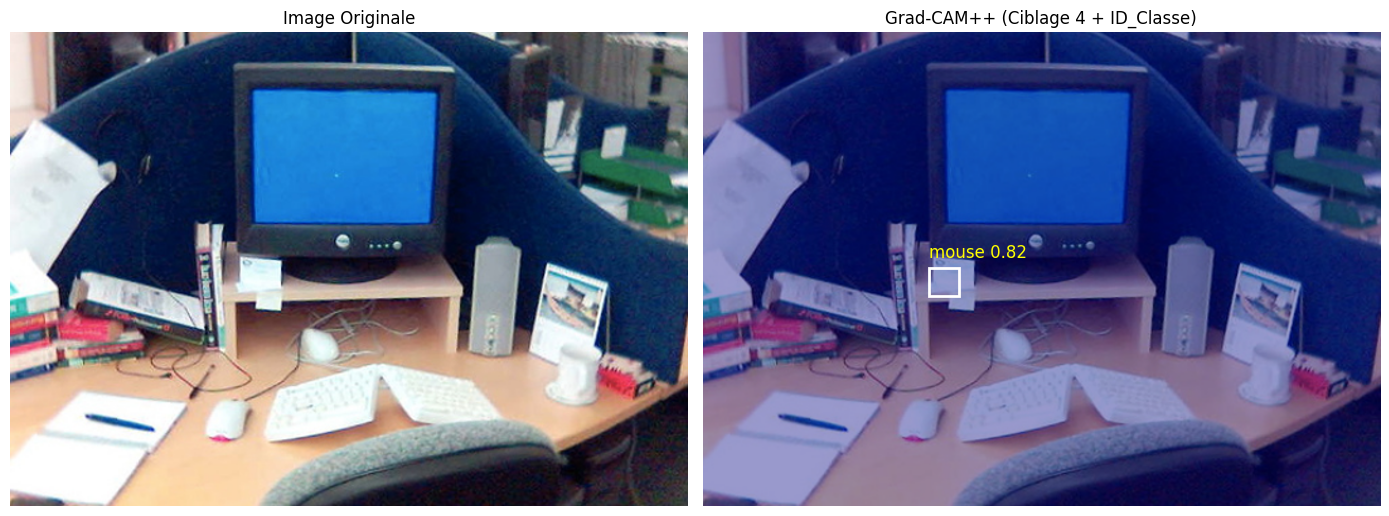

In [15]:

img_np = np.array(img_final)
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_pp), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
alpha = 0.4
superimposed_img = cv2.addWeighted(img_np, 1 - alpha, heatmap_rgb, alpha, 0)


fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(img_np)
ax[0].set_title("Image Originale")
ax[0].axis('off')

ax[1].imshow(superimposed_img)
ax[1].set_title('Grad-CAM++ (Ciblage 4 + ID_Classe)')
ax[1].axis('off') 

if results and len(results[0].boxes):
    names = yolo_model.names 
    box = results[0].boxes[0] 
    
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='white', linewidth=2)
    ax[1].add_patch(rect)
    ax[1].text(x1, y1 - 10, f'{names[int(box.cls)]} {box.conf.item():.2f}', 
               color='yellow', fontsize=12)

plt.tight_layout()
plt.show()